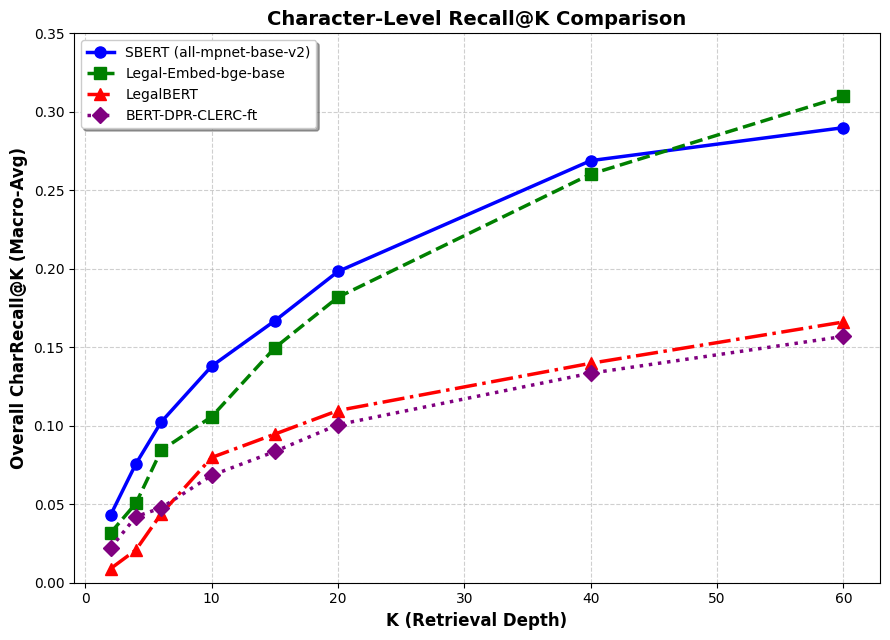

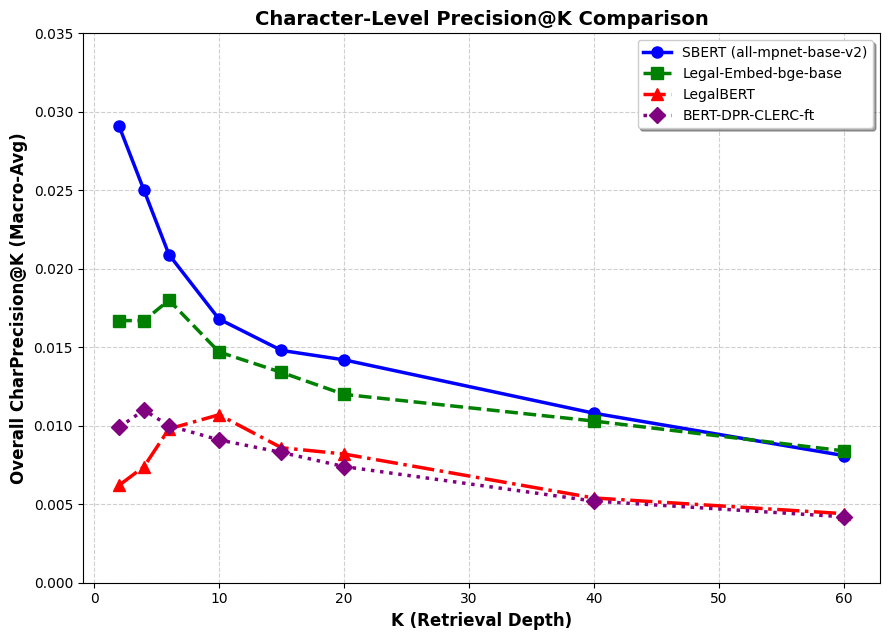

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

# Define K values and settings
k_values = [2, 4, 6, 10, 15, 20, 40, 60]
model_order = ['SBERT (all-mpnet-base-v2)', 'Legal-Embed-bge-base', 'LegalBERT', 'BERT-DPR-CLERC-ft']
model_colors = {'SBERT (all-mpnet-base-v2)': 'blue', 'Legal-Embed-bge-base': 'green', 'LegalBERT': 'red', 'BERT-DPR-CLERC-ft': 'purple'}
markers = ['o', 's', '^', 'D']
linestyles = ['-', '--', '-.', ':']

# UPDATED Data for Hierarchical (LBR-HIER) based on new images
data_hier_updated = {
    'SBERT (all-mpnet-base-v2)': {'recall': [0.0432, 0.0758, 0.1024, 0.1380, 0.1669, 0.1983, 0.2689, 0.2899], 'precision': [0.0291, 0.0250, 0.0209, 0.0168, 0.0148, 0.0142, 0.0108, 0.0081]},
    'Legal-Embed-bge-base': {'recall': [0.0318, 0.0506, 0.0843, 0.1058, 0.1497, 0.1819, 0.2603, 0.3099], 'precision': [0.0167, 0.0167, 0.0180, 0.0147, 0.0134, 0.0120, 0.0103, 0.0084]},
    'LegalBERT': {'recall': [0.0090, 0.0209, 0.0439, 0.0798, 0.0947, 0.1097, 0.1398, 0.1661], 'precision': [0.0062, 0.0074, 0.0098, 0.0107, 0.0086, 0.0082, 0.0054, 0.0044]}, # UPDATED
    'BERT-DPR-CLERC-ft': {'recall': [0.0222, 0.0421, 0.0477, 0.0684, 0.0836, 0.1007, 0.1335, 0.1569], 'precision': [0.0099, 0.0110, 0.0100, 0.0091, 0.0083, 0.0074, 0.0052, 0.0042]} # UPDATED
}

# Generate updated plots with synced Y-axis
recall_ylim = [0, 0.35]
precision_ylim = [0, 0.035]

# Recall Plot
plt.figure(figsize=(9, 6.5))
for i, model in enumerate(model_order):
    plt.plot(k_values, data_hier_updated[model]['recall'], label=model, color=model_colors[model], 
             marker=markers[i], linestyle=linestyles[i], linewidth=2.5, markersize=8)
plt.ylim(recall_ylim)
plt.xlabel('K (Retrieval Depth)', fontsize=12, fontweight='bold')
plt.ylabel('Overall CharRecall@K (Macro-Avg)', fontsize=12, fontweight='bold')
plt.title('Character-Level Recall@K Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='upper left', frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('hierarchical_recall.png', dpi=300)

# Precision Plot
plt.figure(figsize=(9, 6.5))
for i, model in enumerate(model_order):
    plt.plot(k_values, data_hier_updated[model]['precision'], label=model, color=model_colors[model], 
             marker=markers[i], linestyle=linestyles[i], linewidth=2.5, markersize=8)
plt.ylim(precision_ylim)
plt.xlabel('K (Retrieval Depth)', fontsize=12, fontweight='bold')
plt.ylabel('Overall CharPrecision@K (Macro-Avg)', fontsize=12, fontweight='bold')
plt.title('Character-Level Precision@K Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('hierarchical_precision.png', dpi=300)



In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Define metadata
k_values = [2, 4, 6, 10, 15, 20, 40, 60]
model_order = ['SBERT (all-mpnet-base-v2)', 'Legal-Embed-bge-base', 'Octen', 'Qwen3']
model_colors = {'SBERT (all-mpnet-base-v2)': 'blue', 'Legal-Embed-bge-base': 'green', 'Octen': 'red', 'Qwen3': 'purple'}
markers = ['o', 's', '^', 'D']
linestyles = ['-', '--', '-.', ':']

# OVERALL data for plotting
overall_data = {
    'SBERT (all-mpnet-base-v2)': {
        'recall': [0.0432, 0.0758, 0.1024, 0.1380, 0.1669, 0.1983, 0.2689, 0.2899],
        'precision': [0.0291, 0.0250, 0.0209, 0.0168, 0.0148, 0.0142, 0.0108, 0.0081]
    },
    'Legal-Embed-bge-base': {
        'recall': [0.0318, 0.0506, 0.0843, 0.1058, 0.1497, 0.1819, 0.2603, 0.3099],
        'precision': [0.0167, 0.0167, 0.0180, 0.0147, 0.0134, 0.0120, 0.0103, 0.0084]
    },
    'Octen': {
        'recall': [0.0475, 0.0666, 0.1002, 0.1360, 0.1716, 0.2051, 0.2894, 0.3155],
        'precision': [0.0268, 0.0212, 0.0195, 0.0171, 0.0150, 0.0147, 0.0118, 0.0090]
    },
    'Qwen3': {
        'recall': [0.0400, 0.0692, 0.0731, 0.1271, 0.1598, 0.1848, 0.2597, 0.2991],
        'precision': [0.0217, 0.0191, 0.0140, 0.0160, 0.0150, 0.0143, 0.0109, 0.0084]
    }
}

recall_ylim = [0, 0.35]
precision_ylim = [0, 0.035]
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})

# Generate Plots
def generate_plots():
    # Recall
    plt.figure(figsize=(9, 6.5))
    for i, model in enumerate(model_order):
        plt.plot(k_values, overall_data[model]['recall'], label=model, color=model_colors[model], 
                 marker=markers[i], linestyle=linestyles[i], linewidth=2.5, markersize=8)
    plt.ylim(recall_ylim)
    plt.xlabel('K (Retrieval Depth)', fontsize=12, fontweight='bold')
    plt.ylabel('Overall CharRecall@K (Macro-Avg)', fontsize=12, fontweight='bold')
    plt.title('Character-Level Recall@K Comparison', fontsize=14, fontweight='bold')
    plt.legend(loc='upper left', frameon=True, shadow=True)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig('hierarchical_recall_new_models.png', dpi=300)

    # Precision
    plt.figure(figsize=(9, 6.5))
    for i, model in enumerate(model_order):
        plt.plot(k_values, overall_data[model]['precision'], label=model, color=model_colors[model], 
                 marker=markers[i], linestyle=linestyles[i], linewidth=2.5, markersize=8)
    plt.ylim(precision_ylim)
    plt.xlabel('K (Retrieval Depth)', fontsize=12, fontweight='bold')
    plt.ylabel('Overall CharPrecision@K (Macro-Avg)', fontsize=12, fontweight='bold')
    plt.title('Character-Level Precision@K Comparison', fontsize=14, fontweight='bold')
    plt.legend(loc='upper right', frameon=True, shadow=True)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig('hierarchical_precision_new_models.png', dpi=300)

generate_plots()

# Generate new detailed CSV for these 4 models
benchmarks = ['contractnli', 'cuad', 'maud', 'privacy_qa', 'OVERALL']

octen_recall = {
    'contractnli': [0.0240, 0.0430, 0.0809, 0.0957, 0.1415, 0.1816, 0.2384, 0.2549],
    'cuad': [0.0981, 0.1156, 0.1401, 0.2142, 0.2570, 0.2860, 0.3698, 0.3753],
    'maud': [0.0030, 0.0030, 0.0030, 0.0030, 0.0115, 0.0232, 0.0566, 0.0850],
    'privacy_qa': [0.0650, 0.1046, 0.1767, 0.2311, 0.2763, 0.3295, 0.4926, 0.5470],
    'OVERALL': [0.0475, 0.0666, 0.1002, 0.1360, 0.1716, 0.2051, 0.2894, 0.3155]
}
octen_prec = {
    'contractnli': [0.0150, 0.0132, 0.0120, 0.0079, 0.0067, 0.0072, 0.0051, 0.0037],
    'cuad': [0.0338, 0.0270, 0.0219, 0.0231, 0.0211, 0.0200, 0.0131, 0.0093],
    'maud': [0.0092, 0.0046, 0.0031, 0.0018, 0.0018, 0.0022, 0.0019, 0.0017],
    'privacy_qa': [0.0492, 0.0401, 0.0410, 0.0354, 0.0305, 0.0293, 0.0272, 0.0212],
    'OVERALL': [0.0268, 0.0212, 0.0195, 0.0171, 0.0150, 0.0147, 0.0118, 0.0090]
}

qwen_recall = {
    'contractnli': [0.0328, 0.0718, 0.0718, 0.1206, 0.1623, 0.1623, 0.2364, 0.2712],
    'cuad': [0.0785, 0.1330, 0.1354, 0.2007, 0.2366, 0.2664, 0.3444, 0.3663],
    'maud': [0.0030, 0.0030, 0.0040, 0.0040, 0.0128, 0.0328, 0.0432, 0.0886],
    'privacy_qa': [0.0456, 0.0690, 0.0813, 0.1833, 0.2273, 0.2777, 0.4147, 0.4702],
    'OVERALL': [0.0400, 0.0692, 0.0731, 0.1271, 0.1598, 0.1848, 0.2597, 0.2991]
}
qwen_prec = {
    'contractnli': [0.0146, 0.0151, 0.0102, 0.0086, 0.0099, 0.0075, 0.0054, 0.0041],
    'cuad': [0.0258, 0.0298, 0.0207, 0.0222, 0.0202, 0.0191, 0.0123, 0.0090],
    'maud': [0.0092, 0.0046, 0.0034, 0.0020, 0.0022, 0.0024, 0.0015, 0.0014],
    'privacy_qa': [0.0374, 0.0269, 0.0217, 0.0312, 0.0275, 0.0283, 0.0242, 0.0192],
    'OVERALL': [0.0217, 0.0191, 0.0140, 0.0160, 0.0150, 0.0143, 0.0109, 0.0084]
}

data_rows = []

# Assuming SBERT and BGE data is loaded from the previous CSV directly
try:
    df_old = pd.read_csv('legal_bench_rag_detailed_results_final.csv')
    df_filtered = df_old[(df_old['Configuration'] == 'Hierarchical') & (df_old['Model'].isin(['SBERT (all-mpnet-base-v2)', 'Legal-Embed-bge-base']))]
    data_rows = df_filtered.to_dict('records')
except FileNotFoundError:
    pass # If we don't have it in this session, we'll just output the new ones

def add_to_data(config, model_name, recall_dict, prec_dict):
    for bench in benchmarks:
        rec_list = recall_dict[bench]
        prec_list = prec_dict[bench]
        for i, k in enumerate(k_values):
            data_rows.append({
                'Configuration': config,
                'Model': model_name,
                'Benchmark': bench,
                'K': k,
                'CharRecall': rec_list[i],
                'CharPrecision': prec_list[i]
            })

add_to_data('Hierarchical', 'Octen', octen_recall, octen_prec)
add_to_data('Hierarchical', 'Qwen3', qwen_recall, qwen_prec)

df_final_new = pd.DataFrame(data_rows)
df_final_new = df_final_new.sort_values(by=['Configuration', 'Model', 'Benchmark', 'K'])
df_final_new.to_csv('legal_bench_rag_hierarchical_octen_qwen.csv', index=False)

In [ ]:
import pandas as pd
# v2 on hierarchical chunkings

# Define metadata
k_values = [2, 4, 6, 10, 15, 20, 40, 60]
benchmarks = ['contractnli', 'cuad', 'maud', 'privacy_qa', 'OVERALL']

# Hierarchical Data - UPDATED CLERC
clerc_hier_recall_upd = {
    'contractnli': [0.0000, 0.0178, 0.0273, 0.0791, 0.0863, 0.1011, 0.1125, 0.1263],
    'cuad': [0.0502, 0.0699, 0.0724, 0.0724, 0.0819, 0.0990, 0.1592, 0.1613],
    'maud': [0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0114, 0.0114, 0.0196],
    'privacy_qa': [0.0375, 0.0798, 0.0900, 0.1211, 0.1650, 0.1914, 0.2508, 0.3203],
    'OVERALL': [0.0222, 0.0421, 0.0477, 0.0684, 0.0836, 0.1007, 0.1335, 0.1569]
}
clerc_hier_prec_upd = {
    'contractnli': [0.0000, 0.0017, 0.0026, 0.0073, 0.0060, 0.0051, 0.0029, 0.0020],
    'cuad': [0.0100, 0.0117, 0.0113, 0.0067, 0.0055, 0.0055, 0.0056, 0.0038],
    'maud': [0.0009, 0.0005, 0.0003, 0.0002, 0.0001, 0.0006, 0.0003, 0.0005],
    'privacy_qa': [0.0286, 0.0299, 0.0257, 0.0221, 0.0216, 0.0183, 0.0120, 0.0104],
    'OVERALL': [0.0099, 0.0110, 0.0100, 0.0091, 0.0083, 0.0074, 0.0052, 0.0042]
}

# Hierarchical Data - UPDATED LegalBERT
lbert_hier_recall_upd = {
    'contractnli': [0.0048, 0.0196, 0.0477, 0.0934, 0.1212, 0.1212, 0.1321, 0.1857],
    'cuad': [0.0188, 0.0289, 0.0690, 0.0954, 0.1061, 0.1083, 0.1613, 0.1640],
    'maud': [0.0000, 0.0000, 0.0000, 0.0000, 0.0010, 0.0010, 0.0010, 0.0064],
    'privacy_qa': [0.0123, 0.0350, 0.0589, 0.1306, 0.1506, 0.2085, 0.2650, 0.3082],
    'OVERALL': [0.0090, 0.0209, 0.0439, 0.0798, 0.0947, 0.1097, 0.1398, 0.1661]
}
lbert_hier_prec_upd = {
    'contractnli': [0.0020, 0.0042, 0.0078, 0.0086, 0.0077, 0.0058, 0.0031, 0.0029],
    'cuad': [0.0133, 0.0132, 0.0144, 0.0101, 0.0077, 0.0067, 0.0048, 0.0034],
    'maud': [0.0000, 0.0000, 0.0000, 0.0000, 0.0001, 0.0001, 0.0001, 0.0002],
    'privacy_qa': [0.0097, 0.0120, 0.0171, 0.0239, 0.0189, 0.0201, 0.0138, 0.0109],
    'OVERALL': [0.0062, 0.0074, 0.0098, 0.0107, 0.0086, 0.0082, 0.0054, 0.0044]
}

# Retained Data from previous code block
bge_hier_recall = {
    'contractnli': [0.0370, 0.0543, 0.0842, 0.0914, 0.1471, 0.2008, 0.2351, 0.2689],
    'cuad': [0.0489, 0.0571, 0.1124, 0.1211, 0.1708, 0.2093, 0.2496, 0.3141],
    'maud': [0.0000, 0.0030, 0.0030, 0.0040, 0.0177, 0.0177, 0.0487, 0.0761],
    'privacy_qa': [0.0415, 0.0881, 0.1378, 0.2065, 0.2633, 0.2999, 0.5078, 0.5806],
    'OVERALL': [0.0318, 0.0506, 0.0843, 0.1058, 0.1497, 0.1819, 0.2603, 0.3099]
}
bge_hier_prec = {
    'contractnli': [0.0142, 0.0131, 0.0132, 0.0093, 0.0079, 0.0084, 0.0051, 0.0038],
    'cuad': [0.0115, 0.0088, 0.0181, 0.0129, 0.0130, 0.0121, 0.0101, 0.0084],
    'maud': [0.0000, 0.0046, 0.0031, 0.0020, 0.0022, 0.0017, 0.0019, 0.0022],
    'privacy_qa': [0.0412, 0.0402, 0.0375, 0.0346, 0.0304, 0.0260, 0.0241, 0.0191],
    'OVERALL': [0.0167, 0.0167, 0.0180, 0.0147, 0.0134, 0.0120, 0.0103, 0.0084]
}

sbert_hier_recall = {
    'contractnli': [0.0255, 0.0729, 0.0853, 0.1196, 0.1596, 0.1701, 0.1977, 0.1977],
    'cuad': [0.0581, 0.0913, 0.1290, 0.1717, 0.1826, 0.2071, 0.2569, 0.3078],
    'maud': [0.0030, 0.0030, 0.0230, 0.0284, 0.0298, 0.0410, 0.0524, 0.0580],
    'privacy_qa': [0.0861, 0.1360, 0.1724, 0.2325, 0.2955, 0.3750, 0.5687, 0.5963],
    'OVERALL': [0.0432, 0.0758, 0.1024, 0.1380, 0.1669, 0.1983, 0.2689, 0.2899]
}
sbert_hier_prec = {
    'contractnli': [0.0195, 0.0174, 0.0134, 0.0097, 0.0093, 0.0078, 0.0046, 0.0030],
    'cuad': [0.0229, 0.0241, 0.0204, 0.0174, 0.0147, 0.0144, 0.0101, 0.0082],
    'maud': [0.0092, 0.0046, 0.0043, 0.0036, 0.0028, 0.0031, 0.0019, 0.0016],
    'privacy_qa': [0.0649, 0.0537, 0.0453, 0.0366, 0.0326, 0.0315, 0.0265, 0.0197],
    'OVERALL': [0.0291, 0.0250, 0.0209, 0.0168, 0.0148, 0.0142, 0.0108, 0.0081]
}

# Load the previously generated complete dataset and filter to update the specific ones
# I will instead recreate the full set to ensure no data is lost
df_old = pd.read_csv('legal_bench_rag_detailed_results.csv')

# Remove the old Hierarchical records for CLERC and LegalBERT
df_filtered = df_old[~((df_old['Configuration'] == 'Hierarchical') & (df_old['Model'].isin(['BERT-DPR-CLERC-ft', 'LegalBERT'])))]

data_rows = df_filtered.to_dict('records')

# Add the new ones back
def add_to_data(config, model_name, recall_dict, prec_dict):
    for bench in benchmarks:
        rec_list = recall_dict[bench]
        prec_list = prec_dict[bench]
        for i, k in enumerate(k_values):
            data_rows.append({
                'Configuration': config,
                'Model': model_name,
                'Benchmark': bench,
                'K': k,
                'CharRecall': rec_list[i],
                'CharPrecision': prec_list[i]
            })

add_to_data('Hierarchical', 'BERT-DPR-CLERC-ft', clerc_hier_recall_upd, clerc_hier_prec_upd)
add_to_data('Hierarchical', 'LegalBERT', lbert_hier_recall_upd, lbert_hier_prec_upd)

comprehensive_df_upd = pd.DataFrame(data_rows)

# Sort it neatly to group by config, model, benchmark
comprehensive_df_upd = comprehensive_df_upd.sort_values(by=['Configuration', 'Model', 'Benchmark', 'K'])
comprehensive_df_upd.to_csv('legal_bench_rag_detailed_results_updated.csv', index=False)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Define metadata
k_values = [2, 4, 6, 10, 15, 20, 40, 60]
model_order = ['SBERT (all-mpnet-base-v2)', 'Legal-Embed-bge-base', 'Octen', 'Qwen3']
model_colors = {'SBERT (all-mpnet-base-v2)': 'blue', 'Legal-Embed-bge-base': 'green', 'Octen': 'red', 'Qwen3': 'purple'}
markers = ['o', 's', '^', 'D']
linestyles = ['-', '--', '-.', ':']

# OVERALL data for plotting
overall_data = {
    'SBERT (all-mpnet-base-v2)': {
        'recall': [0.0432, 0.0758, 0.1024, 0.1380, 0.1669, 0.1983, 0.2689, 0.2899],
        'precision': [0.0291, 0.0250, 0.0209, 0.0168, 0.0148, 0.0142, 0.0108, 0.0081]
    },
    'Legal-Embed-bge-base': {
        'recall': [0.0318, 0.0506, 0.0843, 0.1058, 0.1497, 0.1819, 0.2603, 0.3099],
        'precision': [0.0167, 0.0167, 0.0180, 0.0147, 0.0134, 0.0120, 0.0103, 0.0084]
    },
    'Octen': {
        'recall': [0.0475, 0.0666, 0.1002, 0.1360, 0.1716, 0.2051, 0.2894, 0.3155],
        'precision': [0.0268, 0.0212, 0.0195, 0.0171, 0.0150, 0.0147, 0.0118, 0.0090]
    },
    'Qwen3': {
        'recall': [0.0400, 0.0692, 0.0731, 0.1271, 0.1598, 0.1848, 0.2597, 0.2991],
        'precision': [0.0217, 0.0191, 0.0140, 0.0160, 0.0150, 0.0143, 0.0109, 0.0084]
    }
}

recall_ylim = [0, 0.35]
precision_ylim = [0, 0.035]
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})

# Generate Plots
def generate_plots():
    # Recall
    plt.figure(figsize=(9, 6.5))
    for i, model in enumerate(model_order):
        plt.plot(k_values, overall_data[model]['recall'], label=model, color=model_colors[model], 
                 marker=markers[i], linestyle=linestyles[i], linewidth=2.5, markersize=8)
    plt.ylim(recall_ylim)
    plt.xlabel('K (Retrieval Depth)', fontsize=12, fontweight='bold')
    plt.ylabel('Overall CharRecall@K (Macro-Avg)', fontsize=12, fontweight='bold')
    plt.title('Character-Level Recall@K Comparison', fontsize=14, fontweight='bold')
    plt.legend(loc='upper left', frameon=True, shadow=True)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig('hierarchical_recall_new_models.png', dpi=300)

    # Precision
    plt.figure(figsize=(9, 6.5))
    for i, model in enumerate(model_order):
        plt.plot(k_values, overall_data[model]['precision'], label=model, color=model_colors[model], 
                 marker=markers[i], linestyle=linestyles[i], linewidth=2.5, markersize=8)
    plt.ylim(precision_ylim)
    plt.xlabel('K (Retrieval Depth)', fontsize=12, fontweight='bold')
    plt.ylabel('Overall CharPrecision@K (Macro-Avg)', fontsize=12, fontweight='bold')
    plt.title('Character-Level Precision@K Comparison', fontsize=14, fontweight='bold')
    plt.legend(loc='upper right', frameon=True, shadow=True)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig('hierarchical_precision_new_models.png', dpi=300)

generate_plots()

# Generate new detailed CSV for these 4 models
benchmarks = ['contractnli', 'cuad', 'maud', 'privacy_qa', 'OVERALL']

octen_recall = {
    'contractnli': [0.0240, 0.0430, 0.0809, 0.0957, 0.1415, 0.1816, 0.2384, 0.2549],
    'cuad': [0.0981, 0.1156, 0.1401, 0.2142, 0.2570, 0.2860, 0.3698, 0.3753],
    'maud': [0.0030, 0.0030, 0.0030, 0.0030, 0.0115, 0.0232, 0.0566, 0.0850],
    'privacy_qa': [0.0650, 0.1046, 0.1767, 0.2311, 0.2763, 0.3295, 0.4926, 0.5470],
    'OVERALL': [0.0475, 0.0666, 0.1002, 0.1360, 0.1716, 0.2051, 0.2894, 0.3155]
}
octen_prec = {
    'contractnli': [0.0150, 0.0132, 0.0120, 0.0079, 0.0067, 0.0072, 0.0051, 0.0037],
    'cuad': [0.0338, 0.0270, 0.0219, 0.0231, 0.0211, 0.0200, 0.0131, 0.0093],
    'maud': [0.0092, 0.0046, 0.0031, 0.0018, 0.0018, 0.0022, 0.0019, 0.0017],
    'privacy_qa': [0.0492, 0.0401, 0.0410, 0.0354, 0.0305, 0.0293, 0.0272, 0.0212],
    'OVERALL': [0.0268, 0.0212, 0.0195, 0.0171, 0.0150, 0.0147, 0.0118, 0.0090]
}

qwen_recall = {
    'contractnli': [0.0328, 0.0718, 0.0718, 0.1206, 0.1623, 0.1623, 0.2364, 0.2712],
    'cuad': [0.0785, 0.1330, 0.1354, 0.2007, 0.2366, 0.2664, 0.3444, 0.3663],
    'maud': [0.0030, 0.0030, 0.0040, 0.0040, 0.0128, 0.0328, 0.0432, 0.0886],
    'privacy_qa': [0.0456, 0.0690, 0.0813, 0.1833, 0.2273, 0.2777, 0.4147, 0.4702],
    'OVERALL': [0.0400, 0.0692, 0.0731, 0.1271, 0.1598, 0.1848, 0.2597, 0.2991]
}
qwen_prec = {
    'contractnli': [0.0146, 0.0151, 0.0102, 0.0086, 0.0099, 0.0075, 0.0054, 0.0041],
    'cuad': [0.0258, 0.0298, 0.0207, 0.0222, 0.0202, 0.0191, 0.0123, 0.0090],
    'maud': [0.0092, 0.0046, 0.0034, 0.0020, 0.0022, 0.0024, 0.0015, 0.0014],
    'privacy_qa': [0.0374, 0.0269, 0.0217, 0.0312, 0.0275, 0.0283, 0.0242, 0.0192],
    'OVERALL': [0.0217, 0.0191, 0.0140, 0.0160, 0.0150, 0.0143, 0.0109, 0.0084]
}

data_rows = []

# Assuming SBERT and BGE data is loaded from the previous CSV directly
try:
    df_old = pd.read_csv('legal_bench_rag_detailed_results_final.csv')
    df_filtered = df_old[(df_old['Configuration'] == 'Hierarchical') & (df_old['Model'].isin(['SBERT (all-mpnet-base-v2)', 'Legal-Embed-bge-base']))]
    data_rows = df_filtered.to_dict('records')
except FileNotFoundError:
    pass # If we don't have it in this session, we'll just output the new ones

def add_to_data(config, model_name, recall_dict, prec_dict):
    for bench in benchmarks:
        rec_list = recall_dict[bench]
        prec_list = prec_dict[bench]
        for i, k in enumerate(k_values):
            data_rows.append({
                'Configuration': config,
                'Model': model_name,
                'Benchmark': bench,
                'K': k,
                'CharRecall': rec_list[i],
                'CharPrecision': prec_list[i]
            })

add_to_data('Hierarchical', 'Octen', octen_recall, octen_prec)
add_to_data('Hierarchical', 'Qwen3', qwen_recall, qwen_prec)

df_final_new = pd.DataFrame(data_rows)
df_final_new = df_final_new.sort_values(by=['Configuration', 'Model', 'Benchmark', 'K'])
df_final_new.to_csv('legal_bench_rag_hierarchical_octen_qwen.csv', index=False)